# 01. Sign Event Gate Overlay Probe

이 노트북의 목적은 **YOLO 표지판 detection을 실제 주행 이벤트로 인정할 조건**을 눈으로 확인하는 것이다.

00 노트북에서 확인한 것은 다음에 가까웠다.

```text
이미지 → YOLO → bbox / class / confidence 출력
```

01 노트북에서는 그 다음 단계만 본다.

```text
YOLO detection
→ conf / bbox 크기(area_ratio) / bbox 위치(ROI)
→ event로 인정할지 판단
→ overlay로 사람이 검수
```

아직 최종 contract를 확정하지 않는다.  
이 노트북은 **후보 gate를 씌운 overlay를 생성하는 단계**까지만 수행한다.

## 0. 실행 환경 준비

필요 패키지:

- `ultralytics`: YOLO 모델 로드와 추론
- `opencv-python`: 이미지 읽기와 bbox overlay
- `pandas`, `numpy`: 결과 테이블 정리

이미 설치되어 있으면 넘어가고, 없으면 아래 셀에서 설치한다.

In [1]:
import sys
import subprocess
import importlib.util

REQUIRED = ["ultralytics", "cv2", "pandas", "numpy", "PIL"]
missing = []
for name in REQUIRED:
    probe = "cv2" if name == "cv2" else name
    if importlib.util.find_spec(probe) is None:
        missing.append(name)

print("python:", sys.executable)
print("missing:", missing)

if "ultralytics" in missing:
    print("Installing ultralytics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])

python: ~\anaconda3\envs\<env>\python.exe
missing: []


## 1. 경로와 실험 설정

이 노트북은 shared assets에 모아둔 sign 데이터와 sign YOLO 모델을 사용한다.

- dataset: `20_shared_assets/dataset/sign/{class_name}`
- model: `20_shared_assets/models/sign_yolo11n_field2_v1/*.onnx`
- outputs: `10_experiments/20_sign_event_contract/review_outputs/01_sign_event_gate_overlay_probe`

초기 관찰용이므로 기본값은 클래스당 일부 샘플만 사용한다.  
전체 데이터로 보고 싶으면 `MAX_IMAGES_PER_CLASS = None`으로 바꾸면 된다.

In [2]:
from pathlib import Path
import json
import math
import random
import shutil
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
from IPython.display import display, Image as IPyImage
from ultralytics import YOLO

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
EXP_ROOT = PROJECT_ROOT / "10_experiments" / "20_sign_event_contract"
DATASET_ROOT = PROJECT_ROOT / "20_shared_assets" / "dataset" / "sign"
MODEL_ROOT = PROJECT_ROOT / "20_shared_assets" / "models" / "sign_yolo11n_field2_v1"

OUT_ROOT = EXP_ROOT / "review_outputs" / "01_sign_event_gate_overlay_probe"
TABLE_DIR = OUT_ROOT / "tables"
OVERLAY_DIR = OUT_ROOT / "overlays"
for p in [OUT_ROOT, TABLE_DIR, OVERLAY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["horn", "left", "right", "speed_20", "stop", "straight"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# 첫 관찰용 샘플 수. 전체 데이터로 보고 싶으면 None으로 바꾼다.
MAX_IMAGES_PER_CLASS = 80
RANDOM_SEED = 0

# YOLO raw 관찰 threshold. event threshold보다 낮게 잡아서 후보를 넉넉하게 본다.
OBS_CONF = 0.20
OBS_IOU = 0.45
IMG_SIZE = 640

# overlay에 보여줄 이미지 수. 너무 많으면 sheet가 커져서 보기 힘들다.
SHEET_IMAGES_PER_CLASS = 12
MIXED_SHEET_IMAGES = 18

print("dataset:", DATASET_ROOT)
print("model root:", MODEL_ROOT)
print("output:", OUT_ROOT)

dataset: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\sign
model root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1
output: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe


## 2. 모델 선택과 클래스 이름 확인

YOLO ONNX 모델을 불러온다.  
00 노트북에서 확인한 것처럼 이 모델은 6개 class를 출력한다.

```text
horn, left, right, speed_20, stop, straight
```

여기서는 모델을 바꾸지 않는다.  
event gate만 바꾸면서 결과를 본다.

In [3]:
model_candidates = [
    MODEL_ROOT / "sign_yolo11n_field2_light_aug_best.onnx",
    MODEL_ROOT / "sign_yolo11n_field2_clean_best.onnx",
]
MODEL_PATH = next((p for p in model_candidates if p.exists()), None)
assert MODEL_PATH is not None, f"No sign YOLO model found under {MODEL_ROOT}"

model = YOLO(str(MODEL_PATH))
print("selected model:", MODEL_PATH)
print("model names:", model.names)

# 모델 class name이 우리가 기대한 이름과 맞는지 확인한다.
model_names = [model.names[i] for i in sorted(model.names.keys())]
print("ordered names:", model_names)
assert set(model_names) == set(CLASS_NAMES), (model_names, CLASS_NAMES)

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
selected model: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx
Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
model names: {0: 'horn', 1: 'left', 2: 'right', 3: 'speed_20', 4: 'stop', 5: 'straight'}
Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_sha

## 3. Sign Dataset Inventory

폴더명은 이 이미지의 기대 class로 본다.

예:

```text
sign/left/*.jpg → expected_label = left
```

이 단계에서는 detection을 하지 않고, 이미지 개수와 해상도만 확인한다.

In [4]:
def imread_bgr(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def list_images_for_class(label):
    d = DATASET_ROOT / label
    assert d.exists(), d
    all_paths = sorted([p for p in d.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
    usable = []
    skipped = []
    for p in all_paths:
        # 일부 수집 파일이 0바이트로 남아 있으면 Ultralytics 내부 imdecode가 즉시 실패한다.
        # 원본 파일은 삭제하지 않고, 노트북 입력에서만 제외한다.
        reason = None
        try:
            if p.stat().st_size <= 0:
                reason = "zero_byte"
            else:
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is None or img.size == 0:
                    reason = "cv2_unreadable"
        except Exception as e:
            reason = f"read_error:{type(e).__name__}"
        if reason is None:
            usable.append(p)
        else:
            skipped.append({"label": label, "path": str(p), "filename": p.name, "reason": reason})
    return all_paths, usable, skipped

def evenly_sample(paths, max_count, seed=0):
    paths = list(paths)
    if max_count is None or len(paths) <= max_count:
        return paths
    # 순서를 유지한 균등 샘플. 멀리/가까이/조명 차이가 파일명 순서에 섞여 있을 가능성을 보존한다.
    idx = np.linspace(0, len(paths) - 1, max_count).round().astype(int)
    return [paths[i] for i in idx]

records = []
inventory_rows = []
skipped_rows = []
for label in CLASS_NAMES:
    all_paths, usable_paths, skipped = list_images_for_class(label)
    skipped_rows.extend(skipped)
    sample_paths = evenly_sample(usable_paths, MAX_IMAGES_PER_CLASS, RANDOM_SEED)
    wh_counter = {}
    for p in sample_paths[:20]:
        bgr = imread_bgr(p)
        h, w = bgr.shape[:2]
        wh_counter[(w, h)] = wh_counter.get((w, h), 0) + 1
    inventory_rows.append({
        "label": label,
        "all_image_files": len(all_paths),
        "usable_images": len(usable_paths),
        "skipped_images": len(skipped),
        "used_images": len(sample_paths),
        "sample_resolutions_first20": str(dict(wh_counter)),
    })
    for p in sample_paths:
        records.append({"expected_label": label, "path": str(p), "filename": p.name})

records_df = pd.DataFrame(records)
inventory_df = pd.DataFrame(inventory_rows)
skipped_df = pd.DataFrame(skipped_rows)
inventory_df.to_csv(TABLE_DIR / "sign_dataset_inventory.csv", index=False, encoding="utf-8-sig")
skipped_df.to_csv(TABLE_DIR / "skipped_unreadable_images.csv", index=False, encoding="utf-8-sig")
display(inventory_df)
if len(skipped_df):
    print("Skipped unreadable images:", len(skipped_df))
    display(skipped_df.groupby(["label", "reason"]).size().reset_index(name="count"))
print("total used images:", len(records_df))

,label,all_image_files,usable_images,skipped_images,used_images,sample_resolutions_first20
0,horn,701,701,0,80,"{(1296, 972): 20}"
1,left,1033,1033,0,80,"{(1296, 972): 20}"
2,right,760,760,0,80,"{(1296, 972): 20}"
3,speed_20,721,721,0,80,"{(1296, 972): 20}"
4,stop,752,752,0,80,"{(1296, 972): 20}"
5,straight,715,715,0,80,"{(1296, 972): 20}"


total used images: 480


## 4. Raw Detection 관찰

낮은 confidence(`OBS_CONF=0.20`)로 YOLO를 실행한다.

이 단계의 핵심은 **모델이 낸 모든 후보를 저장**하는 것이다.

저장하는 값:

- `pred_label`: YOLO가 예측한 class
- `confidence`: YOLO class confidence
- `bbox`: `x1, y1, x2, y2`
- `cx_norm, cy_norm`: bbox 중심의 정규화 좌표
- `area_ratio`: bbox 면적 / 이미지 면적
- `is_expected`: 폴더명과 예측 class가 일치하는지

이 값들을 이용해 event gate 후보를 만든다.

In [5]:
def yolo_predict_one(path):
    result = model.predict(
        str(path),
        conf=OBS_CONF,
        iou=OBS_IOU,
        imgsz=IMG_SIZE,
        verbose=False,
        device="cpu",
    )[0]
    return result

def result_to_rows(result, rec):
    bgr = imread_bgr(rec["path"])
    h, w = bgr.shape[:2]
    rows = []
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return rows
    xyxy = boxes.xyxy.cpu().numpy()
    conf = boxes.conf.cpu().numpy()
    cls = boxes.cls.cpu().numpy().astype(int)
    for j, (box, c, k) in enumerate(zip(xyxy, conf, cls)):
        x1, y1, x2, y2 = [float(v) for v in box]
        bw = max(0.0, x2 - x1)
        bh = max(0.0, y2 - y1)
        area_ratio = (bw * bh) / float(w * h)
        pred_label = model.names[int(k)]
        rows.append({
            "image_key": f"{rec['expected_label']}::{rec['filename']}",
            "expected_label": rec["expected_label"],
            "filename": rec["filename"],
            "path": rec["path"],
            "pred_label": pred_label,
            "confidence": float(c),
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "w": int(w), "h": int(h),
            "cx_norm": float(((x1 + x2) * 0.5) / w),
            "cy_norm": float(((y1 + y2) * 0.5) / h),
            "area_ratio": float(area_ratio),
            "bbox_w_norm": float(bw / w),
            "bbox_h_norm": float(bh / h),
            "is_expected": bool(pred_label == rec["expected_label"]),
        })
    return rows

raw_rows = []
for i, rec in records_df.iterrows():
    if (i + 1) % 50 == 0:
        print(f"predicting {i + 1}/{len(records_df)}")
    result = yolo_predict_one(rec["path"])
    raw_rows.extend(result_to_rows(result, rec))

raw_df = pd.DataFrame(raw_rows)
raw_df.to_csv(TABLE_DIR / "raw_detections_low_conf.csv", index=False, encoding="utf-8-sig")
print("detections:", len(raw_df))
if len(raw_df):
    display(raw_df.head(10))

Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
predicting 50/480
predicting 100/480
predicting 150/480
predicting 200/480
predicting 250/480
predicting 300/480
predicting 350/480
predicting 400/480
predicting 450/480
detections: 494


,image_key,expected_label,filename,path,pred_label,confidence,x1,y1,x2,y2,w,h,cx_norm,cy_norm,area_ratio,bbox_w_norm,bbox_h_norm,is_expected
0,horn::20260430_174401_signs_horn_moving_mixed_...,horn,20260430_174401_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.332205,822.764526,320.519775,902.421021,369.518188,1296,972,0.665581,0.354958,0.003098,0.061463,0.050410,True
1,horn::20260430_174403_signs_horn_moving_mixed_...,horn,20260430_174403_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.477429,890.262146,306.524353,982.186768,362.718903,1296,972,0.722395,0.344261,0.004101,0.070929,0.057813,True
2,horn::20260430_174403_signs_horn_moving_mixed_...,horn,20260430_174403_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.246363,875.939819,248.622757,1002.276123,386.545837,1296,972,0.724620,0.326733,0.013832,0.097482,0.141896,True
3,horn::20260430_174405_signs_horn_moving_mixed_...,horn,20260430_174405_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.670397,997.398804,254.269989,1118.909180,330.101929,1296,972,0.816477,0.300603,0.007315,0.093758,0.078016,True
4,horn::20260430_174407_signs_horn_moving_mixed_...,horn,20260430_174407_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.652383,958.513062,225.903061,1090.403442,313.844482,1296,972,0.790477,0.277648,0.009207,0.101767,0.090475,True
5,horn::20260430_174409_signs_horn_moving_mixed_...,horn,20260430_174409_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,speed_20,0.741009,0.305800,0.000000,90.113029,217.187454,1296,972,0.034884,0.111722,0.015484,0.069296,0.223444,False
6,horn::20260430_174409_signs_horn_moving_mixed_...,horn,20260430_174409_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.648385,955.155090,179.076447,1118.518555,282.680908,1296,972,0.800028,0.237530,0.013436,0.126052,0.106589,True
7,horn::20260430_174411_signs_horn_moving_mixed_...,horn,20260430_174411_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.661513,931.824585,226.220703,1068.167969,312.762390,1296,972,0.771602,0.277255,0.009367,0.105203,0.089035,True
8,horn::20260430_174411_signs_horn_moving_mixed_...,horn,20260430_174411_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.256869,902.607666,169.011429,1082.276489,360.176422,1296,972,0.765773,0.272216,0.027265,0.138633,0.196672,True
9,horn::20260430_174413_signs_horn_moving_mixed_...,horn,20260430_174413_signs_horn_moving_mixed_right_...,~\02_Projects\University\26-1_Em...,horn,0.565662,821.926880,311.000458,908.444214,363.790436,1296,972,0.667581,0.347115,0.003626,0.066757,0.054311,True


## 5. Detection 분포 요약

여기서는 아직 event 기준을 정하지 않는다.

먼저 class별로 다음을 본다.

- confidence가 어느 정도인지
- bbox 크기(`area_ratio`)가 어느 정도인지
- bbox 중심이 이미지의 어느 위치에 몰리는지
- 기대 class와 맞는 detection이 얼마나 있는지

이 분포를 보고 gate 후보가 너무 느슨한지, 너무 엄격한지 판단한다.

In [6]:
if len(raw_df) == 0:
    raise RuntimeError("No YOLO detections were produced. Check model/data paths.")

summary_rows = []
for label in CLASS_NAMES:
    sub_all = raw_df[raw_df["expected_label"] == label]
    sub_ok = sub_all[sub_all["is_expected"]]
    summary_rows.append({
        "expected_label": label,
        "images": int((records_df["expected_label"] == label).sum()),
        "detections_all": len(sub_all),
        "detections_expected_class": len(sub_ok),
        "conf_p25": float(sub_ok["confidence"].quantile(0.25)) if len(sub_ok) else np.nan,
        "conf_p50": float(sub_ok["confidence"].quantile(0.50)) if len(sub_ok) else np.nan,
        "conf_p75": float(sub_ok["confidence"].quantile(0.75)) if len(sub_ok) else np.nan,
        "area_p25": float(sub_ok["area_ratio"].quantile(0.25)) if len(sub_ok) else np.nan,
        "area_p50": float(sub_ok["area_ratio"].quantile(0.50)) if len(sub_ok) else np.nan,
        "area_p75": float(sub_ok["area_ratio"].quantile(0.75)) if len(sub_ok) else np.nan,
        "cx_p50": float(sub_ok["cx_norm"].quantile(0.50)) if len(sub_ok) else np.nan,
        "cy_p50": float(sub_ok["cy_norm"].quantile(0.50)) if len(sub_ok) else np.nan,
        "right_half_rate": float((sub_ok["cx_norm"] >= 0.5).mean()) if len(sub_ok) else np.nan,
    })

dist_summary = pd.DataFrame(summary_rows)
dist_summary.to_csv(TABLE_DIR / "raw_detection_distribution_by_class.csv", index=False, encoding="utf-8-sig")
display(dist_summary)

# 보기 편한 전체 분포
cols = ["confidence", "area_ratio", "cx_norm", "cy_norm"]
display(raw_df[raw_df["is_expected"]].groupby("expected_label")[cols].describe().round(4))

,expected_label,images,detections_all,detections_expected_class,conf_p25,conf_p50,conf_p75,area_p25,area_p50,area_p75,cx_p50,cy_p50,right_half_rate
0,horn,80,82,79,0.588579,0.648385,0.693424,0.003184,0.004392,0.008628,0.724620,0.338618,1.000000
1,left,80,87,77,0.750914,0.770968,0.787832,0.005536,0.007207,0.014063,0.712842,0.351269,0.948052
2,right,80,95,83,0.524743,0.664595,0.730063,0.005679,0.013982,0.022308,0.796553,0.344533,1.000000
3,speed_20,80,71,71,0.862544,0.885016,0.897843,0.004985,0.009453,0.018616,0.698602,0.377398,1.000000
4,stop,80,78,78,0.730530,0.823849,0.846719,0.003471,0.008785,0.012455,0.694342,0.339340,1.000000
5,straight,80,81,77,0.836174,0.854158,0.864177,0.005986,0.010230,0.018790,0.738252,0.364399,0.974026


confidence                                                  \
                    count    mean     std     min     25%     50%     75%   
expected_label                                                              
horn                 79.0  0.6085  0.1430  0.2011  0.5886  0.6484  0.6934   
left                 77.0  0.7604  0.0716  0.2204  0.7509  0.7710  0.7878   
right                83.0  0.6233  0.1344  0.2066  0.5247  0.6646  0.7301   
speed_20             71.0  0.8595  0.0893  0.4055  0.8625  0.8850  0.8978   
stop                 78.0  0.7793  0.0954  0.5646  0.7305  0.8238  0.8467   
straight             77.0  0.8218  0.1221  0.2276  0.8362  0.8542  0.8642   

                       area_ratio          ... cx_norm         cy_norm  \
                   max      count    mean  ...     75%     max   count   
expected_label                             ...                           
horn            0.9359       79.0  0.0073  ...  0.7837  0.8630    79.0   
left            0.8125       77.0  0.0099  ...  0.8260  0.9270    77.0   
right           0.7937       83.0  0.0152  ...  0.8768  0.9753    83.0   
speed_20        0.9206       71.0  0.0132  ...  0.7661  0.9591    71.0   
stop            0.8679       78.0  0.0115  ...  0.7772  0.9042    78.0   
straight        0.8839       77.0  0.0135  ...  0.8069  0.9227    77.0   

                                                                        
                  mean     std     min     25%     50%     75%     max  
expected_label                                                          
horn            0.3277  0.0381  0.2060  0.3017  0.3386  0.3585  0.3763  
left            0.3459  0.0292  0.2593  0.3256  0.3513  0.3706  0.3927  
right           0.3372  0.0529  0.1887  0.2995  0.3445  0.3720  0.4785  
speed_20        0.3721  0.0275  0.2106  0.3654  0.3774  0.3876  0.3937  
stop            0.3369  0.0453  0.1564  0.3286  0.3393  0.3674  0.3904  
straight        0.3578  0.0298  0.2696  0.3583  0.3644  0.3755  0.4036  

[6 rows x 32 columns]

## 6. Event Gate 후보 정의

여기서 처음으로 event gate 후보를 정의한다.

각 후보는 다음 3가지 조건만 사용한다.

1. `confidence >= min_conf`
2. `area_ratio >= min_area_ratio`
3. bbox 중심이 ROI 안에 있음

현재 후보는 최종값이 아니다.  
overlay를 보고 조정하기 위한 기준선이다.

ROI는 정규화 좌표로 표현한다.

```text
x_min=0.50 → 이미지 오른쪽 절반
x_min=0.55 → 오른쪽으로 조금 더 제한
```

In [7]:
GATE_CANDIDATES = [
    {
        "name": "loose_right_half",
        "min_conf": 0.35,
        "min_area_ratio": 0.0015,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "description": "멀리 있는 표지판까지 넉넉하게 통과시키는 후보",
    },
    {
        "name": "balanced_right_half",
        "min_conf": 0.45,
        "min_area_ratio": 0.0030,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "description": "초기 실주행 후보. 오른쪽 절반 + 중간 수준 conf/area",
    },
    {
        "name": "strict_right_event",
        "min_conf": 0.55,
        "min_area_ratio": 0.0050,
        "roi": {"x_min": 0.55, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "description": "가까운 표지판만 event로 인정하려는 후보",
    },
]

# 필요하면 여기에서 클래스별 override를 실험한다. 지금은 공통 gate만 본다.
CLASS_OVERRIDES = {
    # 예시:
    # "horn": {"min_conf": 0.30},
    # "straight": {"min_area_ratio": 0.0020},
}

pd.DataFrame(GATE_CANDIDATES).to_csv(TABLE_DIR / "gate_candidates.csv", index=False, encoding="utf-8-sig")
display(pd.DataFrame(GATE_CANDIDATES))

,name,min_conf,min_area_ratio,roi,description
0,loose_right_half,0.35,0.0015,"{'x_min': 0.5, 'x_max': 1.0, 'y_min': 0.0, 'y_...",멀리 있는 표지판까지 넉넉하게 통과시키는 후보
1,balanced_right_half,0.45,0.0030,"{'x_min': 0.5, 'x_max': 1.0, 'y_min': 0.0, 'y_...",초기 실주행 후보. 오른쪽 절반 + 중간 수준 conf/area
2,strict_right_event,0.55,0.0050,"{'x_min': 0.55, 'x_max': 1.0, 'y_min': 0.0, 'y...",가까운 표지판만 event로 인정하려는 후보


## 7. Gate 적용 요약

각 이미지마다 gate를 통과한 detection 중 하나를 event 후보로 선택한다.

선택 규칙은 단순하게 둔다.

```text
gate 통과 detection 중 area_ratio가 가장 큰 것
→ 비슷하면 confidence가 높은 것
```

이유는 실제 주행에서 가까운 표지판일수록 bbox가 커지는 경향이 있기 때문이다.  
다중 표지판이 동시에 보이는 경우가 낮다는 가정에서는 이 정도 규칙으로 충분히 출발할 수 있다.

In [8]:
def candidate_params_for_label(candidate, label):
    params = dict(candidate)
    params.update(CLASS_OVERRIDES.get(label, {}))
    return params

def row_passes_gate(row, candidate):
    params = candidate_params_for_label(candidate, row["pred_label"])
    roi = params["roi"]
    if float(row["confidence"]) < float(params["min_conf"]):
        return False
    if float(row["area_ratio"]) < float(params["min_area_ratio"]):
        return False
    if not (float(roi["x_min"]) <= float(row["cx_norm"]) <= float(roi["x_max"])):
        return False
    if not (float(roi["y_min"]) <= float(row["cy_norm"]) <= float(roi["y_max"])):
        return False
    return True

def choose_event_for_image(det_rows, candidate):
    if len(det_rows) == 0:
        return None
    passed = []
    for _, row in det_rows.iterrows():
        if row_passes_gate(row, candidate):
            passed.append(row)
    if not passed:
        return None
    passed_df = pd.DataFrame(passed).sort_values(["area_ratio", "confidence"], ascending=[False, False])
    return passed_df.iloc[0].to_dict()

event_rows = []
for cand in GATE_CANDIDATES:
    for _, rec in records_df.iterrows():
        key = f"{rec['expected_label']}::{rec['filename']}"
        det = raw_df[raw_df["image_key"] == key]
        chosen = choose_event_for_image(det, cand)
        has_expected_det = bool(((det["pred_label"] == rec["expected_label"]) & (det["confidence"] >= OBS_CONF)).any()) if len(det) else False
        if chosen is None:
            event_rows.append({
                "candidate": cand["name"],
                "image_key": key,
                "expected_label": rec["expected_label"],
                "filename": rec["filename"],
                "path": rec["path"],
                "event_label": "none",
                "event_confidence": np.nan,
                "event_area_ratio": np.nan,
                "event_cx_norm": np.nan,
                "event_cy_norm": np.nan,
                "correct_event": False,
                "wrong_event": False,
                "no_event": True,
                "has_expected_detection_low_conf": has_expected_det,
            })
        else:
            event_rows.append({
                "candidate": cand["name"],
                "image_key": key,
                "expected_label": rec["expected_label"],
                "filename": rec["filename"],
                "path": rec["path"],
                "event_label": chosen["pred_label"],
                "event_confidence": float(chosen["confidence"]),
                "event_area_ratio": float(chosen["area_ratio"]),
                "event_cx_norm": float(chosen["cx_norm"]),
                "event_cy_norm": float(chosen["cy_norm"]),
                "correct_event": bool(chosen["pred_label"] == rec["expected_label"]),
                "wrong_event": bool(chosen["pred_label"] != rec["expected_label"]),
                "no_event": False,
                "has_expected_detection_low_conf": has_expected_det,
            })

event_df = pd.DataFrame(event_rows)
event_df.to_csv(TABLE_DIR / "image_event_summary_by_candidate.csv", index=False, encoding="utf-8-sig")

summary_rows = []
for cand_name, sub in event_df.groupby("candidate"):
    summary_rows.append({
        "candidate": cand_name,
        "images": len(sub),
        "event_rate": float((~sub["no_event"]).mean()),
        "correct_event_rate": float(sub["correct_event"].mean()),
        "wrong_event_rate": float(sub["wrong_event"].mean()),
        "no_event_rate": float(sub["no_event"].mean()),
        "mean_event_confidence": float(sub["event_confidence"].mean()),
        "mean_event_area_ratio": float(sub["event_area_ratio"].mean()),
    })

candidate_summary = pd.DataFrame(summary_rows)
candidate_summary.to_csv(TABLE_DIR / "candidate_summary.csv", index=False, encoding="utf-8-sig")
display(candidate_summary)

per_class_summary = event_df.groupby(["candidate", "expected_label"])[["correct_event", "wrong_event", "no_event"]].mean().reset_index()
per_class_summary.to_csv(TABLE_DIR / "candidate_per_class_summary.csv", index=False, encoding="utf-8-sig")
display(per_class_summary)

,candidate,images,event_rate,correct_event_rate,wrong_event_rate,no_event_rate,mean_event_confidence,mean_event_area_ratio
0,balanced_right_half,480,0.843750,0.841667,0.002083,0.156250,0.767591,0.012558
1,loose_right_half,480,0.916667,0.912500,0.004167,0.083333,0.756290,0.011913
2,strict_right_event,480,0.593750,0.591667,0.002083,0.406250,0.800098,0.014703


,candidate,expected_label,correct_event,wrong_event,no_event
0,balanced_right_half,horn,0.7000,0.0000,0.3000
1,balanced_right_half,left,0.8875,0.0125,0.1000
2,balanced_right_half,right,0.8750,0.0000,0.1250
3,balanced_right_half,speed_20,0.8750,0.0000,0.1250
4,balanced_right_half,stop,0.8125,0.0000,0.1875
5,balanced_right_half,straight,0.9000,0.0000,0.1000
6,loose_right_half,horn,0.8625,0.0000,0.1375
7,loose_right_half,left,0.8750,0.0250,0.1000
8,loose_right_half,right,0.9750,0.0000,0.0250
9,loose_right_half,speed_20,0.8875,0.0000,0.1125


## 8. Overlay 생성 함수

Overlay 색상 의미:

- **초록 bbox**: gate 통과 + 기대 class와 일치
- **주황 bbox**: gate 통과했지만 기대 class와 다름. 실제 주행이면 잘못된 event 위험
- **회색 bbox**: YOLO detection은 되었지만 gate에서 탈락
- **두꺼운 bbox**: 해당 이미지에서 최종 event로 선택된 detection

텍스트가 너무 작게 보일 수 있으므로, 중요한 해석은 색과 bbox 위치/크기 위주로 본다.

In [9]:
def draw_text(img, text, org, scale=0.45, color=(255, 255, 255), bg=(0, 0, 0), thickness=1):
    x, y = org
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    cv2.rectangle(img, (x - 2, y - th - baseline - 2), (x + tw + 2, y + baseline + 2), bg, -1)
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

COLOR_CORRECT = (80, 220, 80)
COLOR_WRONG = (0, 165, 255)
COLOR_REJECT = (160, 160, 160)
COLOR_ROI = (255, 180, 80)


def annotate_image_for_candidate(rec, candidate):
    bgr = imread_bgr(rec["path"])
    h, w = bgr.shape[:2]
    out = bgr.copy()
    key = f"{rec['expected_label']}::{rec['filename']}"
    det = raw_df[raw_df["image_key"] == key]
    event_row = event_df[(event_df["candidate"] == candidate["name"]) & (event_df["image_key"] == key)].iloc[0]
    event_label = event_row["event_label"]
    event_box_id = None

    chosen = choose_event_for_image(det, candidate)
    if chosen is not None:
        event_box_id = (
            round(float(chosen["x1"]), 2), round(float(chosen["y1"]), 2),
            round(float(chosen["x2"]), 2), round(float(chosen["y2"]), 2),
            chosen["pred_label"], round(float(chosen["confidence"]), 4)
        )

    # ROI 표시
    roi = candidate["roi"]
    rx1 = int(float(roi["x_min"]) * w)
    ry1 = int(float(roi["y_min"]) * h)
    rx2 = int(float(roi["x_max"]) * w)
    ry2 = int(float(roi["y_max"]) * h)
    overlay = out.copy()
    cv2.rectangle(overlay, (rx1, ry1), (rx2, ry2), COLOR_ROI, -1)
    out = cv2.addWeighted(overlay, 0.10, out, 0.90, 0)
    cv2.rectangle(out, (rx1, ry1), (rx2, ry2), COLOR_ROI, 2)

    for _, row in det.iterrows():
        passes = row_passes_gate(row, candidate)
        is_correct_class = row["pred_label"] == rec["expected_label"]
        color = COLOR_REJECT
        if passes and is_correct_class:
            color = COLOR_CORRECT
        elif passes and not is_correct_class:
            color = COLOR_WRONG
        x1, y1, x2, y2 = [int(round(float(row[v]))) for v in ["x1", "y1", "x2", "y2"]]
        box_id = (
            round(float(row["x1"]), 2), round(float(row["y1"]), 2),
            round(float(row["x2"]), 2), round(float(row["y2"]), 2),
            row["pred_label"], round(float(row["confidence"]), 4)
        )
        thickness = 4 if event_box_id is not None and box_id == event_box_id else 2
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        label = f"{row['pred_label']} {row['confidence']:.2f} ar={row['area_ratio']:.3f}"
        draw_text(out, label, (max(2, x1), max(16, y1 - 3)), scale=0.42, bg=color)

    status = f"GT={rec['expected_label']} | event={event_label} | {candidate['name']}"
    draw_text(out, status, (10, 24), scale=0.58, bg=(20, 20, 20))
    return out


def resize_to_cell(img, cell_w, cell_h):
    h, w = img.shape[:2]
    scale = min(cell_w / w, cell_h / h)
    nw, nh = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((cell_h, cell_w, 3), 245, dtype=np.uint8)
    x0 = (cell_w - nw) // 2
    y0 = (cell_h - nh) // 2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    return canvas


def make_sheet(record_rows, candidate, out_path, title, cols=3, cell_w=520, cell_h=390):
    rows = []
    for _, rec in record_rows.iterrows():
        img = annotate_image_for_candidate(rec, candidate)
        rows.append(resize_to_cell(img, cell_w, cell_h))
    if not rows:
        return None
    n = len(rows)
    grid_cols = cols
    grid_rows = int(math.ceil(n / grid_cols))
    title_h = 52
    sheet = np.full((title_h + grid_rows * cell_h, grid_cols * cell_w, 3), 250, dtype=np.uint8)
    draw_text(sheet, title, (12, 34), scale=0.78, bg=(50, 50, 50))
    for i, img in enumerate(rows):
        r = i // grid_cols
        c = i % grid_cols
        y = title_h + r * cell_h
        x = c * cell_w
        sheet[y:y+cell_h, x:x+cell_w] = img
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), sheet)
    return out_path

print("overlay helpers ready")

overlay helpers ready


## 9. Mixed Overlay 생성

먼저 후보별로 모든 class가 섞인 대표 sheet를 만든다.

이 sheet에서는 후보 gate가 전체적으로 너무 느슨한지/엄격한지 빠르게 본다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\mixed_loose_right_half.jpg


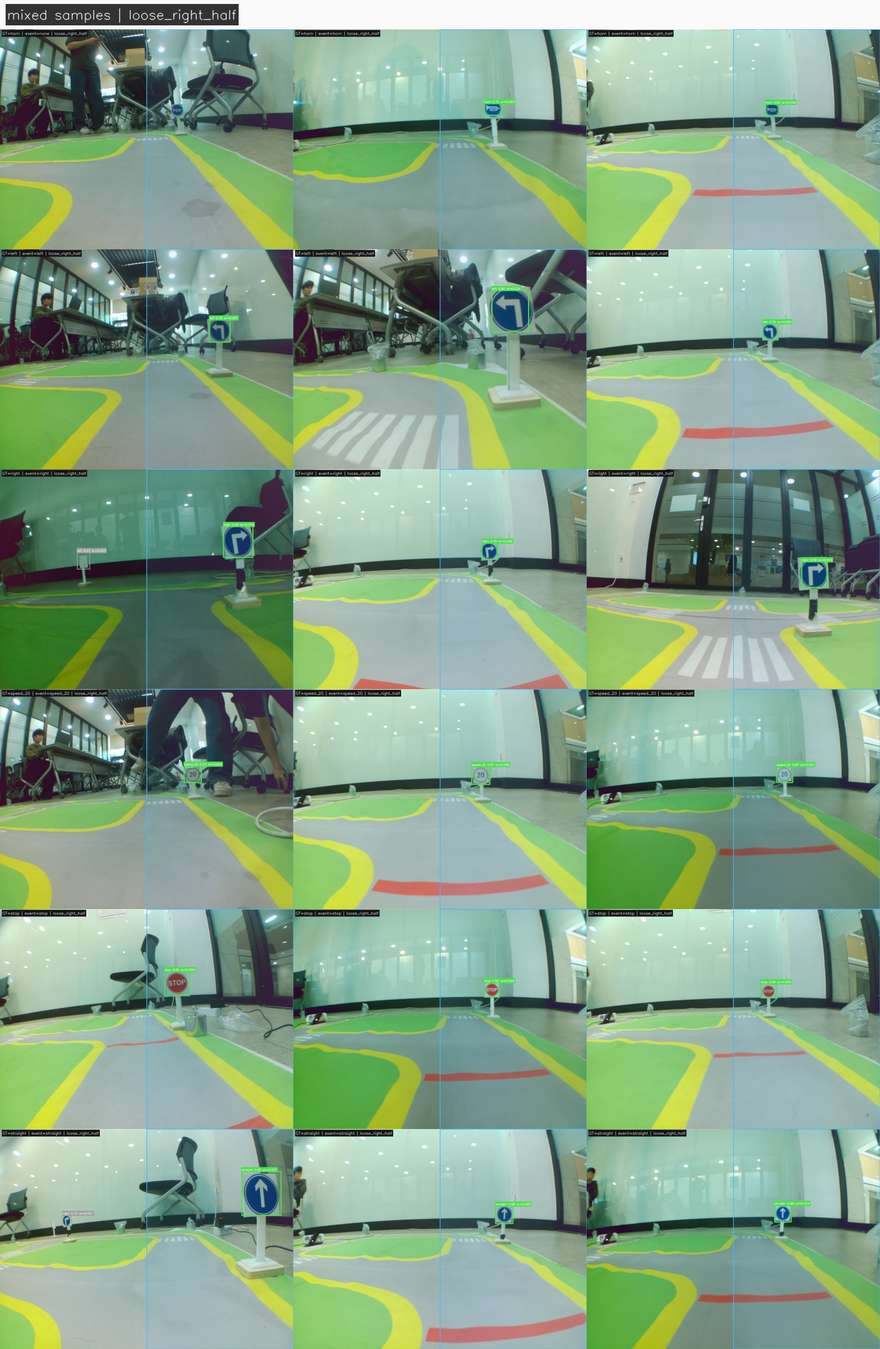

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\mixed_balanced_right_half.jpg


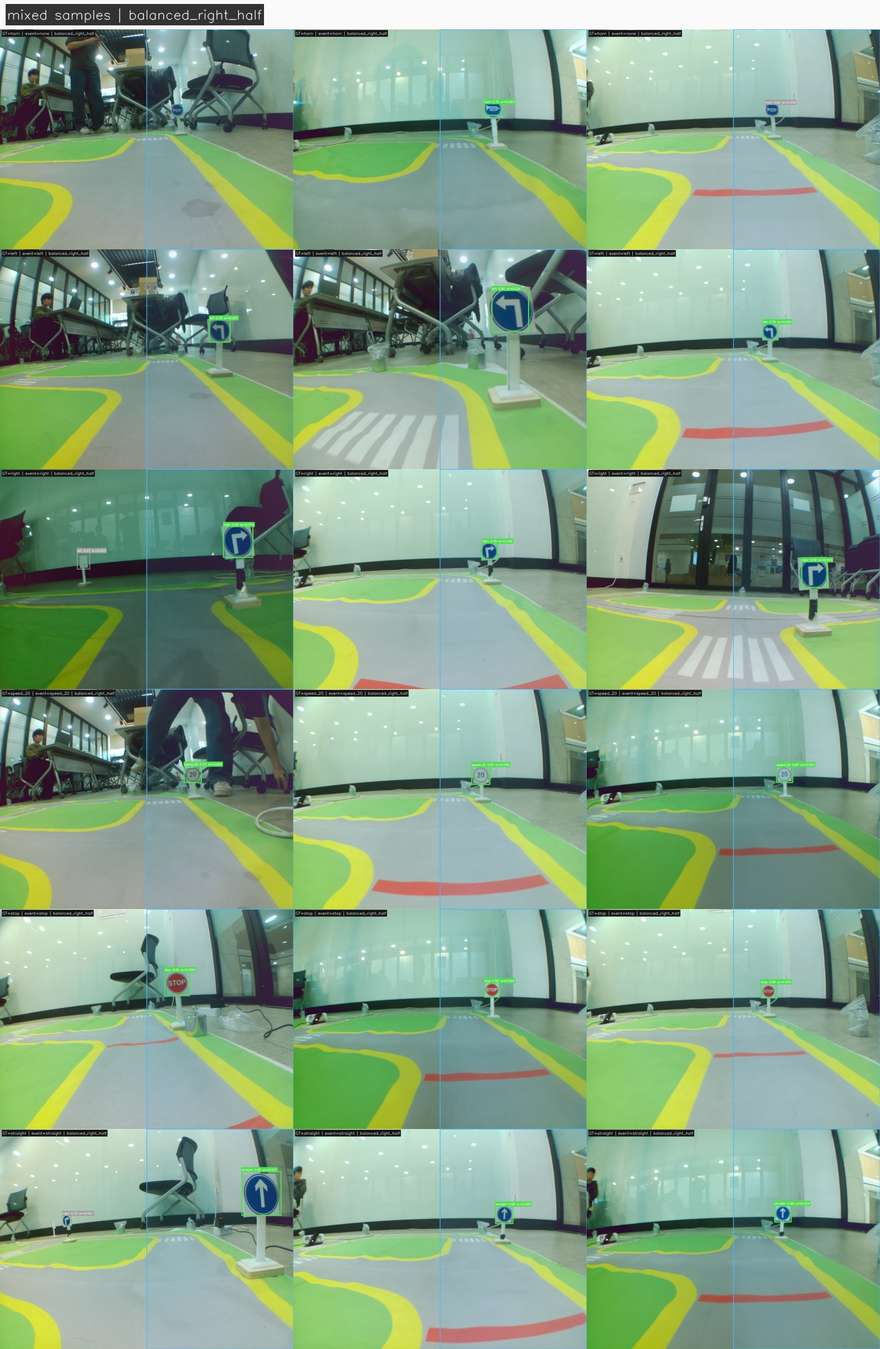

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\mixed_strict_right_event.jpg


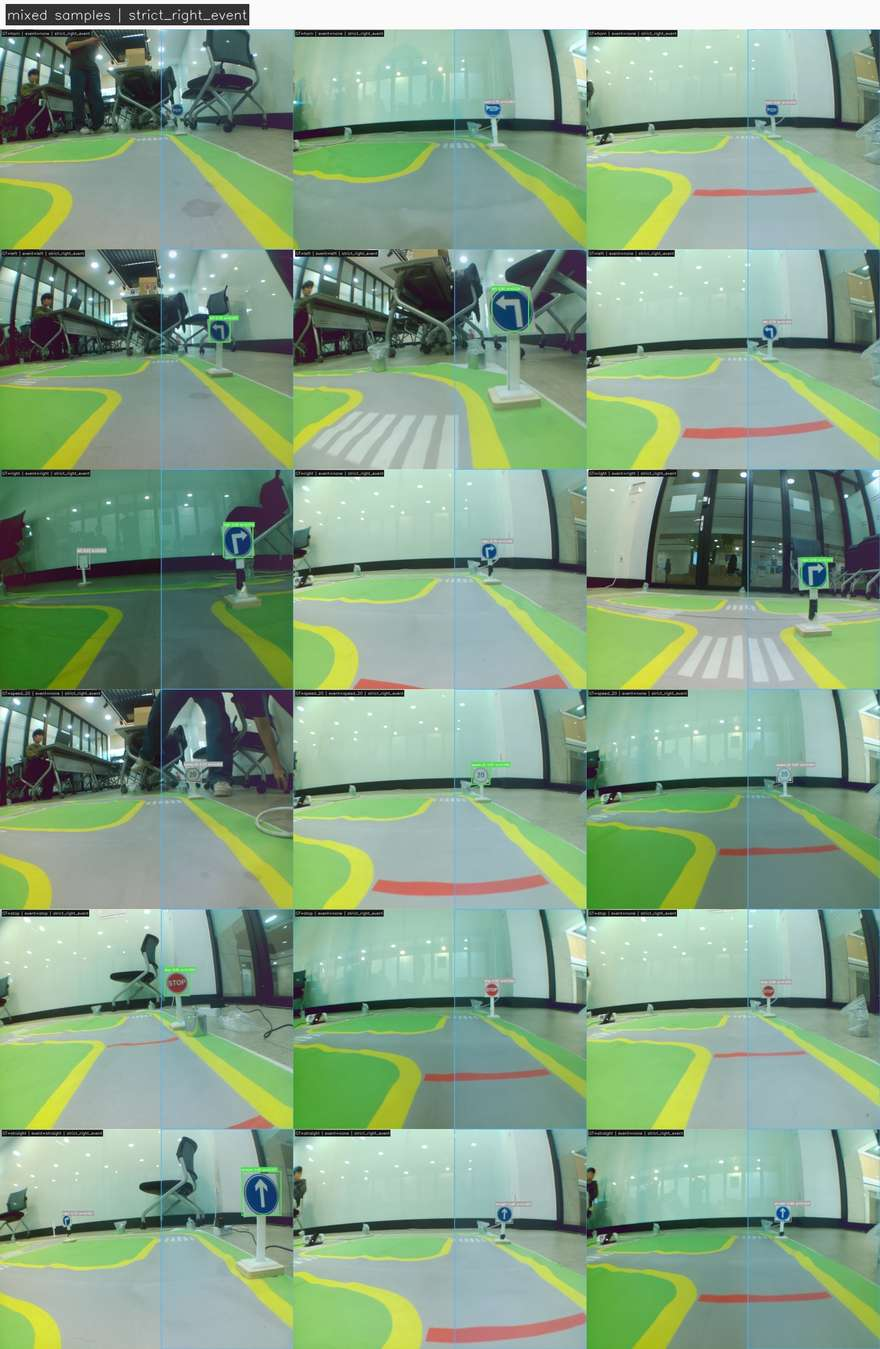

In [10]:
def sample_mixed_records(records_df, n=MIXED_SHEET_IMAGES):
    # class별로 균등하게 섞어 대표 샘플을 만든다.
    per_class = max(1, int(math.ceil(n / len(CLASS_NAMES))))
    parts = []
    for label in CLASS_NAMES:
        sub = records_df[records_df["expected_label"] == label]
        if len(sub) == 0:
            continue
        idx = np.linspace(0, len(sub) - 1, min(per_class, len(sub))).round().astype(int)
        parts.append(sub.iloc[idx])
    mixed = pd.concat(parts, ignore_index=True).head(n)
    return mixed

mixed_records = sample_mixed_records(records_df)
mixed_paths = []
for cand in GATE_CANDIDATES:
    out_path = OVERLAY_DIR / f"mixed_{cand['name']}.jpg"
    make_sheet(mixed_records, cand, out_path, f"mixed samples | {cand['name']}", cols=3)
    mixed_paths.append(out_path)
    print(out_path)
    display(IPyImage(filename=str(out_path)))

## 10. Class별 Overlay 생성

각 class별로 후보 gate overlay를 만든다.

이 단계에서 볼 것:

- 가까운 표지판인데 탈락하는가?
- 너무 먼 표지판인데 event가 뜨는가?
- 다른 class로 잘못 event가 뜨는가?
- 오른쪽 ROI가 너무 넓거나 좁은가?

아직 최종 결정을 하지 않는다.  
생성된 이미지를 보고 다음 노트북 또는 다음 셀에서 threshold를 조정한다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__horn.jpg


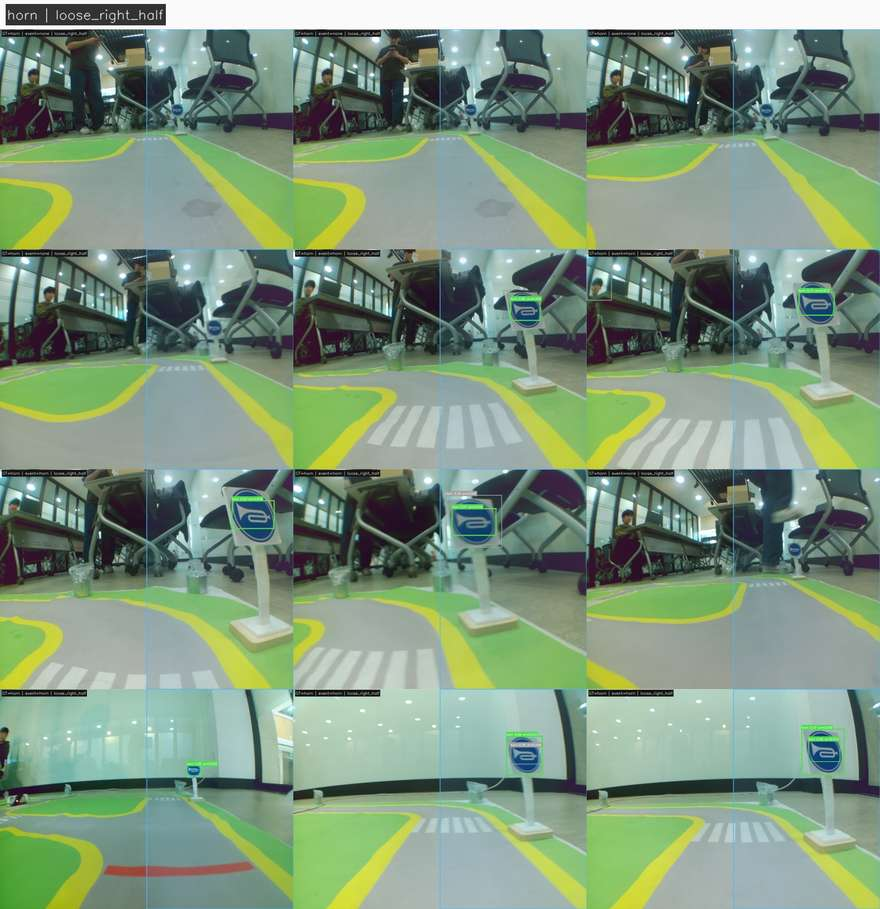

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__left.jpg


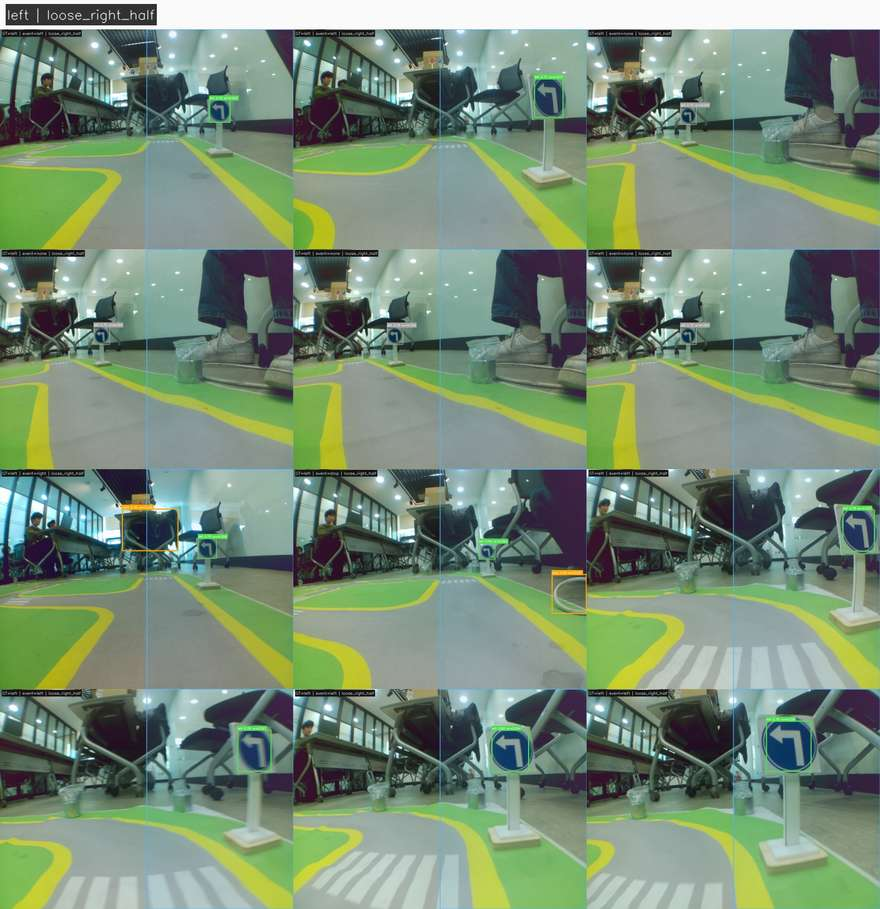

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__right.jpg


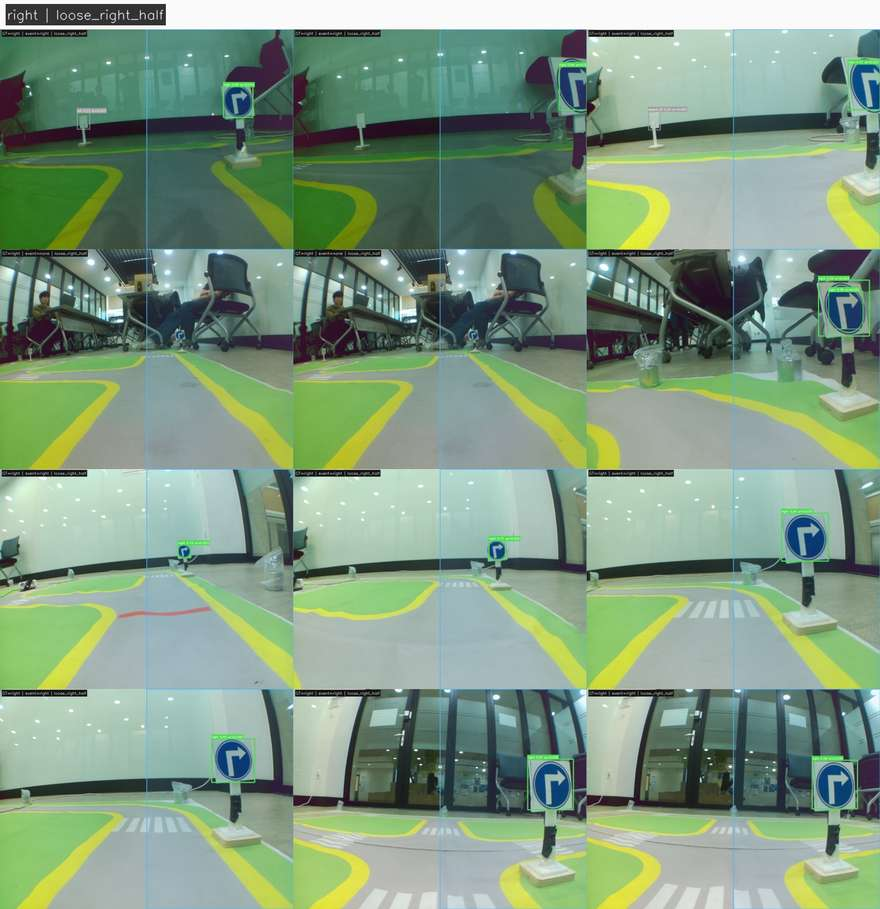

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__speed_20.jpg


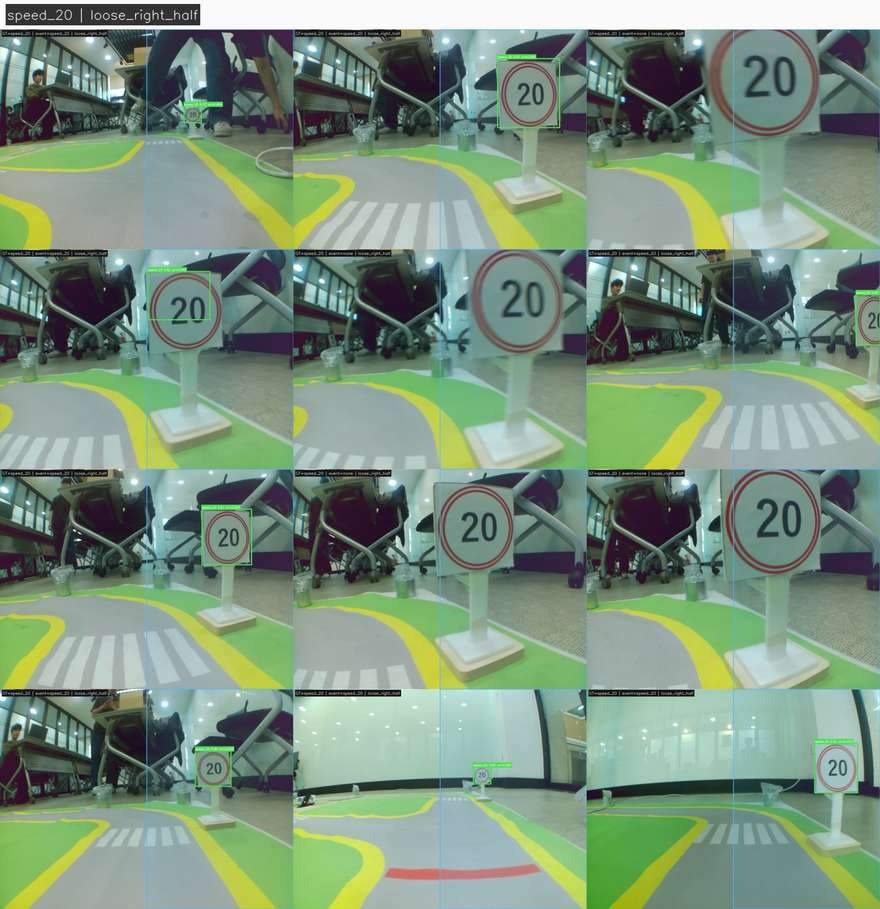

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__stop.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\loose_right_half__straight.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\balanced_right_half__horn.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\balanced_right_half__left.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\balanced_right_half__right.jpg


...

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\strict_right_event__left.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\strict_right_event__right.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\strict_right_event__speed_20.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\strict_right_event__stop.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays\strict_right_event__straight.jpg


In [11]:
def pick_class_records_for_overlay(label, candidate, max_n=SHEET_IMAGES_PER_CLASS):
    sub = event_df[(event_df["candidate"] == candidate["name"]) & (event_df["expected_label"] == label)].copy()
    base = records_df[records_df["expected_label"] == label].copy()
    if len(base) == 0:
        return base

    # 다양한 케이스를 일부러 섞는다: correct, wrong, no_event, 균등 샘플.
    picked_keys = []
    for condition in ["correct_event", "wrong_event", "no_event"]:
        ss = sub[sub[condition] == True]
        if len(ss):
            # event area/conf가 큰 것 위주로 우선 확인
            ss = ss.sort_values(["event_area_ratio", "event_confidence"], ascending=[False, False], na_position="last")
            picked_keys.extend(ss["image_key"].head(4).tolist())
    # 부족하면 균등 샘플로 채운다.
    all_keys = [f"{r.expected_label}::{r.filename}" for r in base.itertuples()]
    if len(all_keys):
        idx = np.linspace(0, len(all_keys) - 1, min(max_n, len(all_keys))).round().astype(int)
        picked_keys.extend([all_keys[i] for i in idx])
    # 순서 유지 unique
    seen = set()
    unique_keys = []
    for k in picked_keys:
        if k not in seen:
            seen.add(k)
            unique_keys.append(k)
    unique_keys = unique_keys[:max_n]
    base = base.copy()
    base["image_key"] = base.apply(lambda r: f"{r['expected_label']}::{r['filename']}", axis=1)
    return base[base["image_key"].isin(unique_keys)]

class_sheet_paths = []
for cand in GATE_CANDIDATES:
    for label in CLASS_NAMES:
        recs = pick_class_records_for_overlay(label, cand)
        out_path = OVERLAY_DIR / f"{cand['name']}__{label}.jpg"
        make_sheet(recs, cand, out_path, f"{label} | {cand['name']}", cols=3)
        class_sheet_paths.append(out_path)
        print(out_path)
        display(IPyImage(filename=str(out_path)))

## 11. 결과 파일 위치

이 노트북은 여기서 멈춘다.

생성된 주요 파일:

- `tables/raw_detections_low_conf.csv`
- `tables/raw_detection_distribution_by_class.csv`
- `tables/candidate_summary.csv`
- `tables/candidate_per_class_summary.csv`
- `overlays/mixed_*.jpg`
- `overlays/{candidate}__{class}.jpg`

다음 단계에서 할 일:

1. overlay를 보고 후보 gate가 너무 느슨한지/엄격한지 판단
2. 필요하면 `GATE_CANDIDATES` 값을 수정해서 다시 Run All
3. 충분히 괜찮아 보이면 02 또는 01b에서 `sign_event_candidate_v1.json`으로 후보 contract 저장

In [12]:
report = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "notebook": "01_sign_event_gate_overlay_probe",
    "model_path": str(MODEL_PATH),
    "dataset_root": str(DATASET_ROOT),
    "max_images_per_class": MAX_IMAGES_PER_CLASS,
    "observation_conf": OBS_CONF,
    "observation_iou": OBS_IOU,
    "img_size": IMG_SIZE,
    "gate_candidates": GATE_CANDIDATES,
    "class_overrides": CLASS_OVERRIDES,
    "outputs": {
        "tables": str(TABLE_DIR),
        "overlays": str(OVERLAY_DIR),
    },
    "note": "This notebook stops at overlay generation. It does not finalize a sign event contract.",
}
with open(OUT_ROOT / "run_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("done")
print("tables:", TABLE_DIR)
print("overlays:", OVERLAY_DIR)
print("report:", OUT_ROOT / "run_report.json")

done
tables: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\tables
overlays: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\overlays
report: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\01_sign_event_gate_overlay_probe\run_report.json
